0       OTHER
1       RRLYR
2         LPV
3         ECL
4       OTHER
        ...  
6784      ECL
6785     DSCT
6786    OTHER
6787      LPV
6788    OTHER
Name: 3, Length: 6789, dtype: str


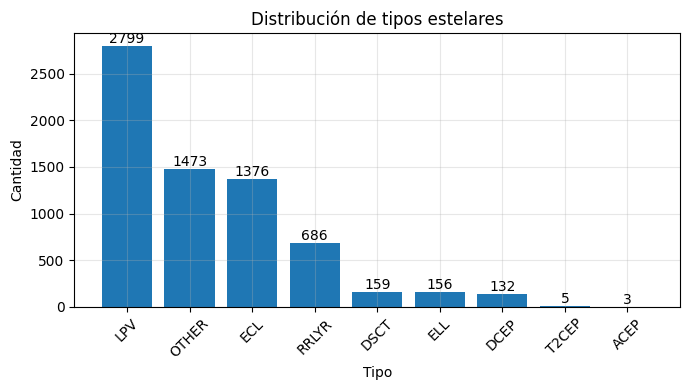

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

#df=pd.read_fwf('/home/anthoni/Documents/MAESTRIA EN FÍSICA/TERCER SEMESTRE/Machine learning astrofísica/Lab10/OGLE4-GSEP-full/phot/I/LMC562.01.2.dat')

df2=pd.read_csv('/home/anthoni/Documents/MAESTRIA EN FÍSICA/3 TERCER SEMESTRE/Machine learning astrofísica/Lab10/OGLE4-GSEP-full/list.dat')
df2 = pd.read_fwf(
    '/home/anthoni/Documents/MAESTRIA EN FÍSICA/3 TERCER SEMESTRE/Machine learning astrofísica/Lab10/OGLE4-GSEP-full/list.dat',
    sep=r'\s+',
    header=None,
    engine='python',
    on_bad_lines='skip'
)
#print(df.head())


tipo = df2.iloc[:,3]
print(tipo)

conteo = tipo.value_counts()

plt.figure(figsize=(7,4))

barras = plt.bar(conteo.index, conteo.values)

# Agregar valores encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{int(altura)}',
        ha='center',
        va='bottom'
    )

plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.title('Distribución de tipos estelares')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('Histogeneral.png')
plt.show()

clase
LPV         2799
Binaria     1532
OTHER       1473
Pulsante     985
Name: count, dtype: int64


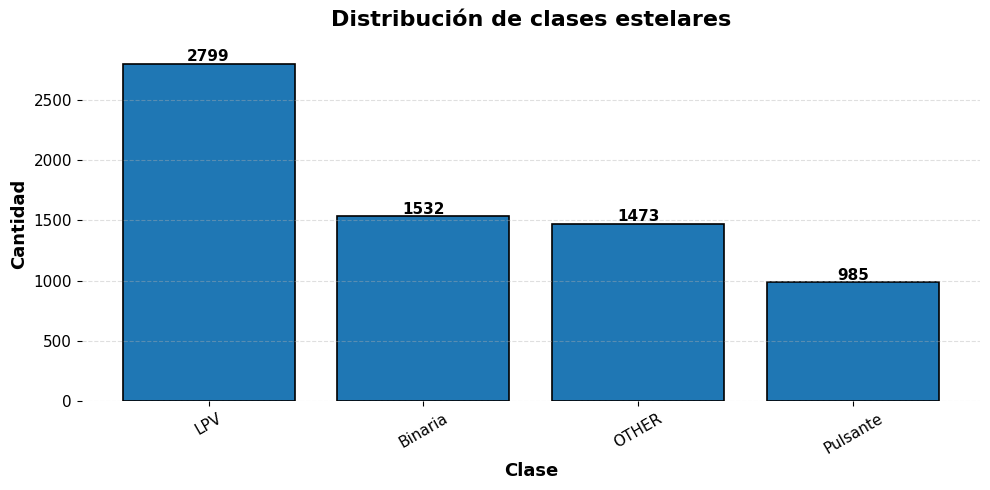

In [3]:
miclase = {
    'LPV':   'LPV',
    'OTHER': 'OTHER',
    'ECL':   'Binaria',
    'ELL':   'Binaria',
    'RRLYR': 'Pulsante',
    'DSCT':  'Pulsante',
    'DCEP':  'Pulsante',
    'T2CEP': 'Pulsante',
    'ACEP':  'Pulsante',
}

df2 = df2.copy()
df2['clase'] = df2.iloc[:, 3].map(miclase)
df4 = df2.dropna(subset=['clase']).copy()  

conteo = df4['clase'].value_counts()
print(conteo)
plt.figure(figsize=(10,5))

# Crear barras
barras = plt.bar(
    conteo.index,
    conteo.values,
    edgecolor='black',
    linewidth=1.2
)

# Valores encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 20,
        f'{int(altura)}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Etiquetas y título
plt.xlabel('Clase', fontsize=13, fontweight='bold')
plt.ylabel('Cantidad', fontsize=13, fontweight='bold')
plt.title(
    'Distribución de clases estelares',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Mejorar ejes
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

# Grid elegante
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Bordes más limpios
plt.box(False)

# Ajustar márgenes
plt.tight_layout()

# Guardar imagen con buena calidad
plt.savefig('Distribucion_clases.png', dpi=300)

plt.show()


In [4]:
n_por_clase = 500

muestra = (
    pd.concat([
        g.sample(n=min(len(g), n_por_clase), random_state=42)
        for _, g in df4.groupby('clase')
    ])
    .reset_index(drop=True)
)

print(muestra['clase'].value_counts())
print('Total:', len(muestra))

clase
Binaria     500
LPV         500
OTHER       500
Pulsante    500
Name: count, dtype: int64
Total: 2000


NaN: 0 de 2000
clase
Binaria     0.38085
LPV         0.03700
OTHER       0.11735
Pulsante    0.42780
Name: amplitud, dtype: float64


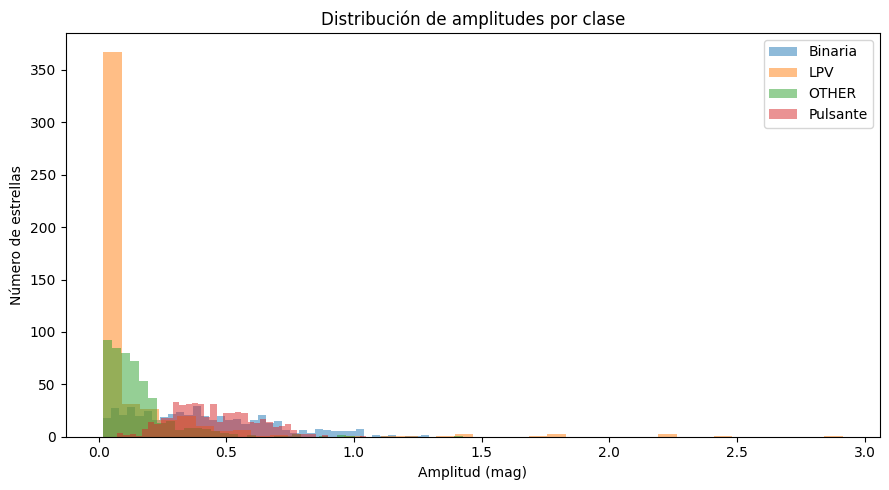

In [5]:
import os
BASE = '/home/anthoni/Documents/MAESTRIA EN FÍSICA/3 TERCER SEMESTRE/Machine learning astrofísica/Lab10/OGLE4-GSEP-full/phot/I'
col_id = 0

def amplitud(star_id):
    ruta = os.path.join(BASE, f'{star_id}.dat')
    try:
        lc = pd.read_csv(ruta, sep=r'\s+', header=None,
                         names=['HJD', 'mag', 'err'])
    except FileNotFoundError:
        return np.nan
    mag = lc['mag'].dropna().values
    if len(mag) < 5:
        return np.nan
    return np.percentile(mag, 95) - np.percentile(mag, 5)

muestra['amplitud'] = muestra.iloc[:, col_id].apply(amplitud)
print('NaN:', muestra['amplitud'].isna().sum(), 'de', len(muestra))
print(muestra.groupby('clase')['amplitud'].median())

amp = muestra.dropna(subset=['amplitud'])   
plt.figure(figsize=(9, 5))
for clase, grupo in amp.groupby('clase'):
    plt.hist(grupo['amplitud'], bins=40, alpha=0.5, label=clase)
#plt.xscale("log")
plt.xlabel('Amplitud (mag)')
plt.ylabel('Número de estrellas')
plt.title('Distribución de amplitudes por clase')
plt.legend()
plt.tight_layout()
plt.show()

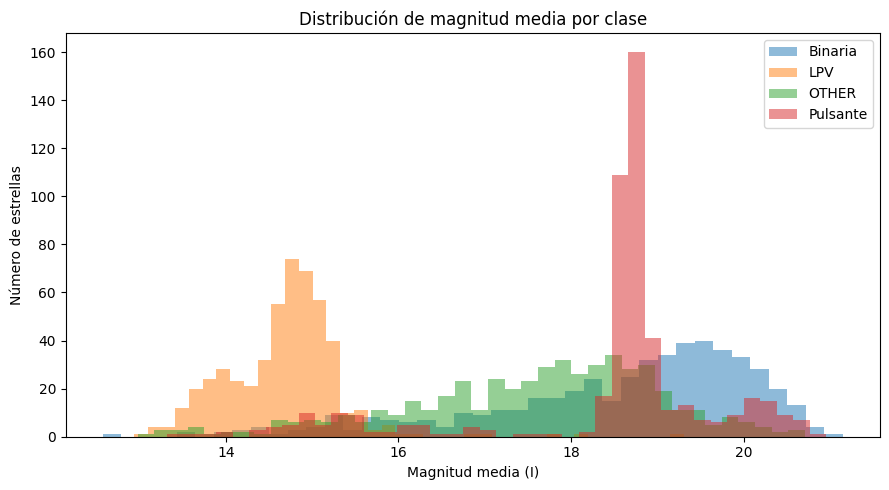

In [6]:
def mag_media(star_id):
    ruta = os.path.join(BASE, f'{star_id}.dat')
    try:
        lc = pd.read_csv(ruta, sep=r'\s+', header=None, names=['HJD', 'mag', 'err'])
    except FileNotFoundError:
        return np.nan
    mag = lc['mag'].dropna().values
    if len(mag) < 5:
        return np.nan
    return np.median(mag)   

muestra['mag_media'] = muestra.iloc[:, col_id].apply(mag_media)

med = muestra.dropna(subset=['mag_media'])
plt.figure(figsize=(9, 5))
for clase, grupo in med.groupby('clase'):
    plt.hist(grupo['mag_media'], bins=40, alpha=0.5, label=clase)

plt.xlabel('Magnitud media (I)')
plt.ylabel('Número de estrellas')
plt.title('Distribución de magnitud media por clase')
plt.legend()
plt.tight_layout()
plt.show()

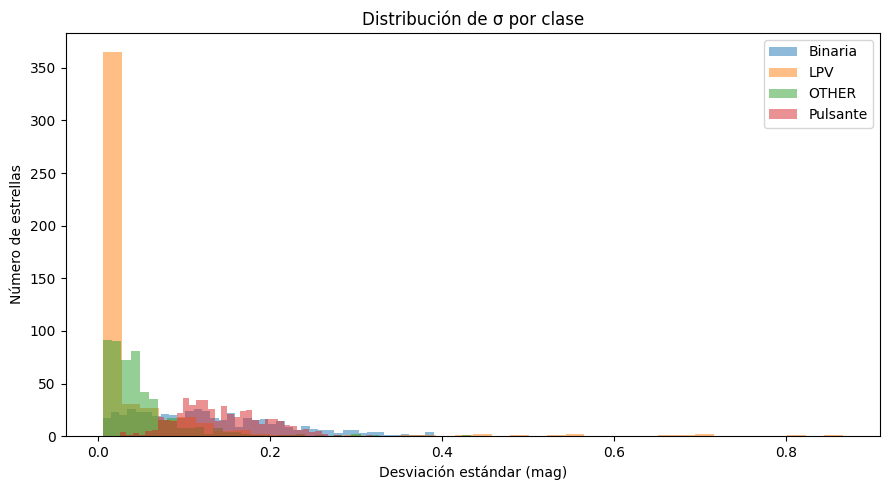

In [7]:
def desv_std(star_id):
    ruta = os.path.join(BASE, f'{star_id}.dat')
    try:
        lc = pd.read_csv(ruta, sep=r'\s+', header=None, names=['HJD', 'mag', 'err'])
    except FileNotFoundError:
        return np.nan
    mag = lc['mag'].dropna().values
    if len(mag) < 5:
        return np.nan
    return np.std(mag)

muestra['std'] = muestra.iloc[:, col_id].apply(desv_std)

s = muestra.dropna(subset=['std'])
plt.figure(figsize=(9, 5))
for clase, grupo in s.groupby('clase'):
    plt.hist(grupo['std'], bins=40, alpha=0.5, label=clase)


plt.xlabel('Desviación estándar (mag)')
plt.ylabel('Número de estrellas')
plt.title('Distribución de σ por clase')
plt.legend()
plt.tight_layout()
plt.show()

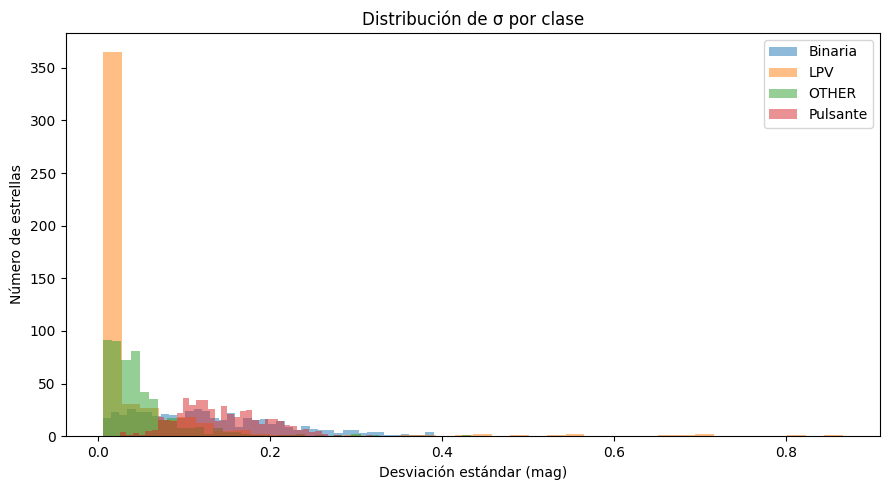

In [8]:
def desv_std(star_id):
    ruta = os.path.join(BASE, f'{star_id}.dat')
    try:
        lc = pd.read_csv(ruta, sep=r'\s+', header=None, names=['HJD', 'mag', 'err'])
    except FileNotFoundError:
        return np.nan
    mag = lc['mag'].dropna().values
    if len(mag) < 5:
        return np.nan
    return np.std(mag)

muestra['std'] = muestra.iloc[:, col_id].apply(desv_std)

s = muestra.dropna(subset=['std'])
plt.figure(figsize=(9, 5))
for clase, grupo in s.groupby('clase'):
    plt.hist(grupo['std'], bins=40, alpha=0.5, label=clase)


plt.xlabel('Desviación estándar (mag)')
plt.ylabel('Número de estrellas')
plt.title('Distribución de σ por clase')
plt.legend()
plt.tight_layout()
plt.show()

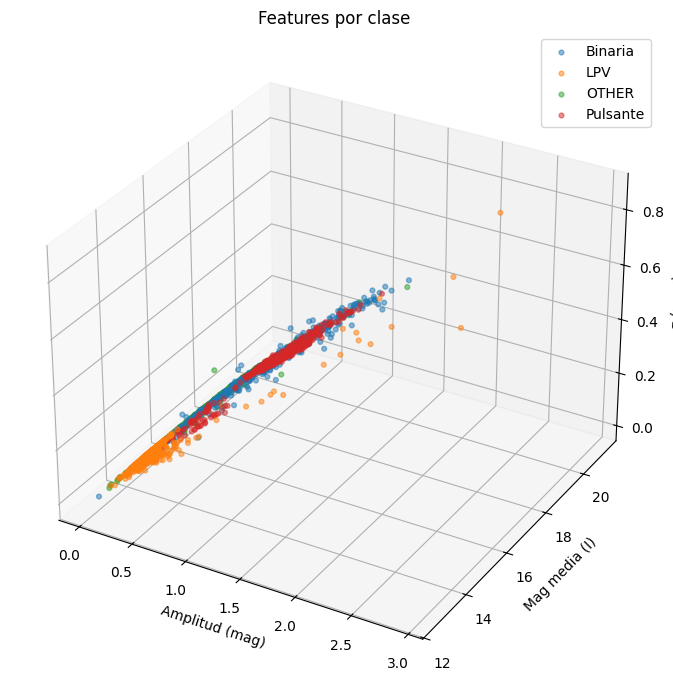

In [9]:
from mpl_toolkits.mplot3d import Axes3D  


d = muestra.dropna(subset=['amplitud', 'mag_media', 'std'])

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for clase, g in d.groupby('clase'):
    ax.scatter(g['amplitud'], g['mag_media'], g['std'],
               label=clase, alpha=0.5, s=12)

ax.set_xlabel('Amplitud (mag)')
ax.set_ylabel('Mag media (I)')
ax.set_zlabel('σ (mag)')
ax.set_title('Features por clase')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
import plotly.express as px   # pip install plotly

d = muestra.dropna(subset=['amplitud', 'mag_media', 'std'])
fig = px.scatter_3d(d, x='amplitud', y='mag_media', z='std',
                    color='clase', opacity=0.6)
fig.update_traces(marker_size=3)
fig.show()

In [11]:
#X = df["I", "P"]

#X.corr("pearson")


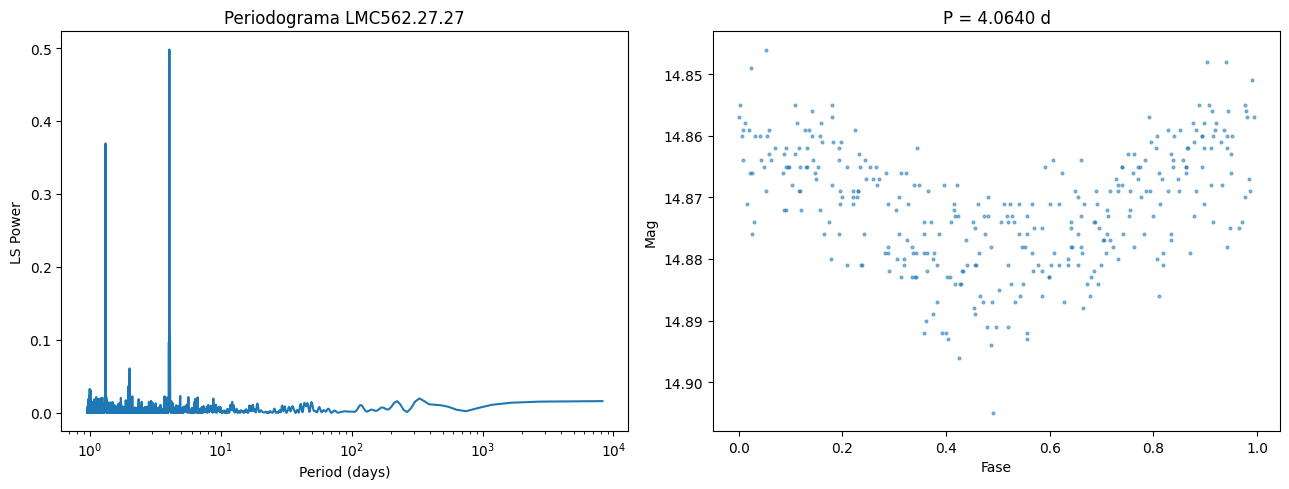

best_frequency: 0.2460604591548863
best_period: 4.0640418352244705


In [12]:
from astropy.timeseries import LombScargle

def analizar(star_id):
    ruta = os.path.join(BASE, f'{star_id}.dat')
    df = pd.read_csv(ruta, sep=r'\s+', header=None,
                     names=['Julian_Date', 'Mag', 'Mag_Error'])
    T = df['Julian_Date'].values
    M = df['Mag'].values
    M_err = df['Mag_Error'].values

    frequency, power = LombScargle(T, M, M_err).autopower()
    best_frequency = frequency[np.argmax(power)]
    best_period = 1 / best_frequency

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

    
    a1.plot(1/frequency, power)
    a1.set_xscale('log')
    a1.set_xlabel('Period (days)'); a1.set_ylabel('LS Power')
    a1.set_title(f'Periodograma {star_id}')

    
    fase = (T % best_period) / best_period
    a2.scatter(fase, M, s=4, alpha=0.5)
    a2.invert_yaxis()
    a2.set_xlabel('Fase'); a2.set_ylabel('Mag')
    a2.set_title(f'P = {best_period:.4f} d')

    plt.tight_layout(); plt.show()
    print('best_frequency:', best_frequency)
    print('best_period:', best_period)


star = muestra[muestra['clase'] == 'OTHER'].iloc[0, col_id]
analizar(star)

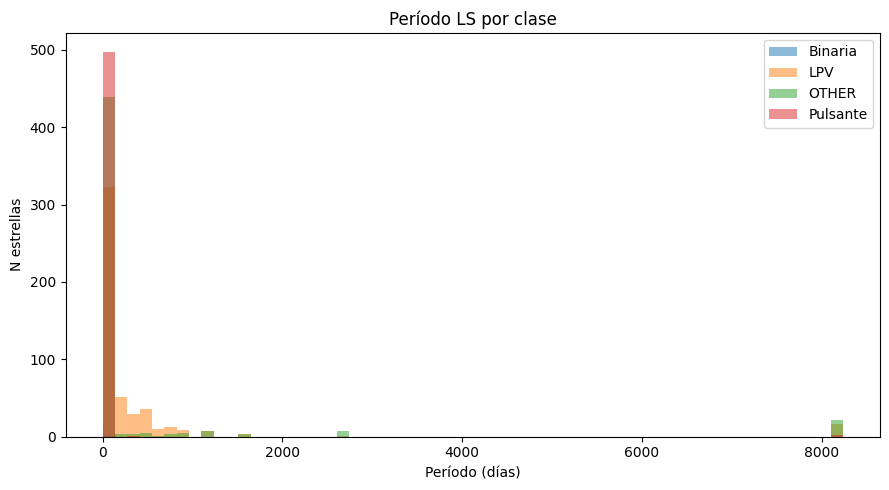

In [13]:
def periodo(star_id):
    ruta = os.path.join(BASE, f'{star_id}.dat')
    try:
        df = pd.read_csv(ruta, sep=r'\s+', header=None,
                         names=['HJD', 'mag', 'err'])
    except FileNotFoundError:
        return np.nan
    if len(df) < 5:
        return np.nan
    freq, power = LombScargle(df['HJD'], df['mag'], df['err']).autopower()
    return 1 / freq[np.argmax(power)]

muestra['periodo'] = muestra.iloc[:, col_id].apply(periodo)

p = muestra.dropna(subset=['periodo'])
plt.figure(figsize=(9, 5))
for clase, g in p.groupby('clase'):
    plt.hist(g['periodo'], bins=60, alpha=0.5, label=clase)


plt.xlabel('Período (días)'); plt.ylabel('N estrellas')
plt.title('Período LS por clase')
plt.legend()
plt.tight_layout(); plt.show()

In [14]:
col6 = pd.to_numeric(muestra.iloc[:, 6], errors='coerce')
col5 = pd.to_numeric(muestra.iloc[:, 5], errors='coerce')
muestra['color'] = col6 - col5

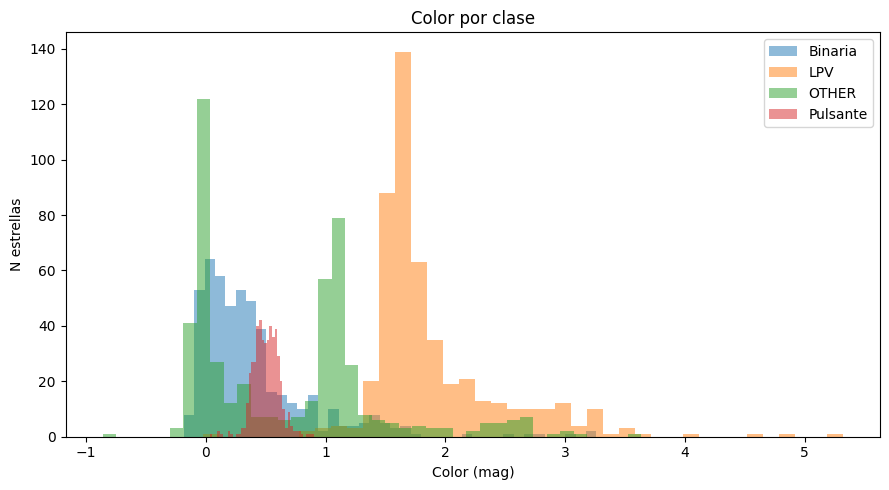

In [15]:


c = muestra.dropna(subset=['color'])
plt.figure(figsize=(9, 5))
for clase, g in c.groupby('clase'):
    plt.hist(g['color'], bins=40, alpha=0.5, label=clase)
plt.xlabel('Color (mag)'); plt.ylabel('N estrellas')
plt.title('Color por clase')
plt.legend()
plt.tight_layout(); plt.show()

In [16]:
# %% [markdown]
# ## Cálculo de features intrínsecas
# Para cada estrella se lee el archivo de curva de luz UNA sola vez y se
# calculan: amplitud, std, skewness, kurtosis, periodo (Lomb-Scargle).
# Todas son invariantes bajo el módulo de distancia.
#
# El `color` se asume ya calculado en `muestra` desde el catálogo.

# %%
import os
from scipy.stats import skew, kurtosis
from tqdm import tqdm
tqdm.pandas()   # habilita .progress_apply

# --- AJUSTAR estas dos cosas a tu setup ---
BASE = ('/home/anthoni/Documents/MAESTRIA EN FÍSICA/3 TERCER SEMESTRE/'
        'Machine learning astrofísica/Lab10/OGLE4-GSEP-full/phot/I')

# Índice posicional de la columna con el star_id en `muestra` (la que usabas)
col_id = 0
# ------------------------------------------


def features_estrella(star_id):
    """Lee la curva de luz y devuelve features intrínsecas.

    Devuelve NaN en todas si el archivo no existe, tiene <20 puntos o
    es constante (std = 0).
    """
    keys = ['amplitud', 'std', 'skewness', 'kurtosis', 'periodo']
    vacio = pd.Series({k: np.nan for k in keys})

    ruta = os.path.join(BASE, f'{star_id}.dat')
    try:
        lc = pd.read_csv(
            ruta, sep=r'\s+', header=None,
            names=['HJD', 'mag', 'err'],
            engine='python', on_bad_lines='skip',
            comment='#',
        )
    except FileNotFoundError:
        return vacio

    lc = lc.dropna(subset=['HJD', 'mag'])
    mag = lc['mag'].to_numpy()
    t = lc['HJD'].to_numpy()

    if len(mag) < 20 or np.std(mag) == 0:
        return vacio

    # --- Estadísticos (invariantes bajo traslación de magnitud) ---
    amplitud = np.percentile(mag, 95) - np.percentile(mag, 5)
    std_v = float(np.std(mag))
    sk = float(skew(mag))
    ku = float(kurtosis(mag))   # Fisher: normal => 0

    # --- Periodo via Lomb-Scargle ---
    # Rango sensato para variables: 0.1 a 1000 días
    try:
        freq, power = LombScargle(t, mag).autopower(
            minimum_frequency=1/1000.0,
            maximum_frequency=10.0,
        )
        periodo = float(1.0 / freq[np.argmax(power)])
    except Exception:
        periodo = np.nan

    return pd.Series({
        'amplitud': amplitud,
        'std': std_v,
        'skewness': sk,
        'kurtosis': ku,
        'periodo': periodo,
    })


# %% Aplicar a TODA la muestra (esto tarda — barra de progreso ayuda)
nuevas_cols = ['amplitud', 'std', 'skewness', 'kurtosis', 'periodo']
muestra[nuevas_cols] = muestra.iloc[:, col_id].progress_apply(features_estrella)


# %% Diagnóstico rápido — lo que pide el "paso 1"
print('--- NaN por feature ---')
features_todas = nuevas_cols + (['color'] if 'color' in muestra.columns else [])
print(muestra[features_todas].isna().sum())

print('\n--- Filas con TODAS las features válidas ---')
validas = muestra.dropna(subset=features_todas)
print(f'{len(validas)} de {len(muestra)} estrellas usables')

print('\n--- Distribución por clase tras filtrar ---')
print(validas['clase'].value_counts())

print('\n--- Resumen estadístico ---')
print(muestra[nuevas_cols].describe().round(3))

100%|██████████| 2000/2000 [04:42<00:00,  7.07it/s]

--- NaN por feature ---
amplitud     0
std          0
skewness     0
kurtosis     0
periodo      0
color       41
dtype: int64

--- Filas con TODAS las features válidas ---
1959 de 2000 estrellas usables

--- Distribución por clase tras filtrar ---
clase
Binaria     492
Pulsante    490
OTHER       489
LPV         488
Name: count, dtype: int64

--- Resumen estadístico ---
       amplitud       std  skewness  kurtosis   periodo
count  2000.000  2000.000  2000.000  2000.000  2000.000
mean      0.292     0.092     0.335     0.678    53.149
std       0.280     0.088     0.785     2.952   172.742
min       0.016     0.005    -1.873    -1.631     0.100
25%       0.066     0.021    -0.102    -0.602     0.546
50%       0.217     0.070     0.125    -0.001     1.001
75%       0.440     0.139     0.532     0.784     9.371
max       2.916     0.867     8.490    76.986  1000.000


Trabajando con 1959 estrellas (de 2000 totales)
clase
Binaria     492
Pulsante    490
OTHER       489
LPV         488
Name: count, dtype: int64


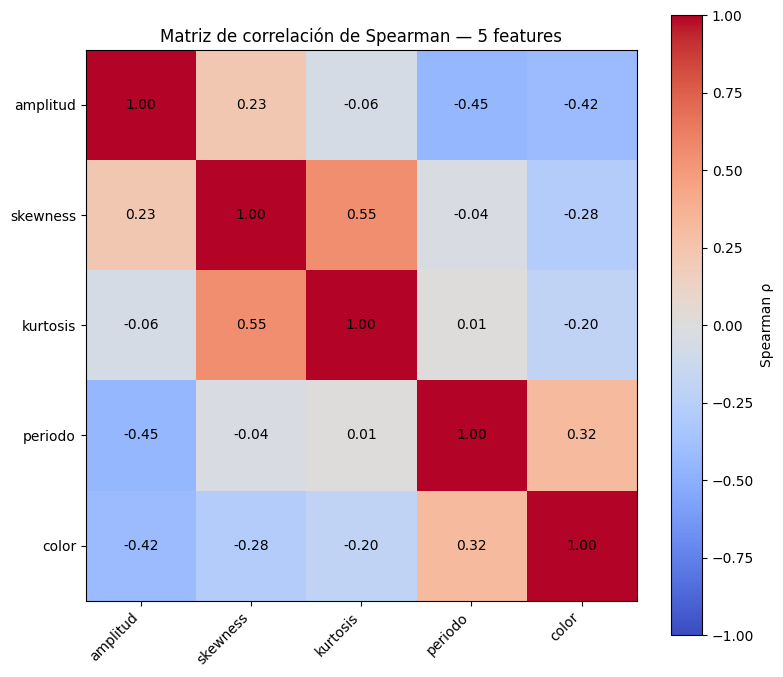


Matriz numérica:
          amplitud  skewness  kurtosis  periodo  color
amplitud      1.00      0.23     -0.06    -0.45  -0.42
skewness      0.23      1.00      0.55    -0.04  -0.28
kurtosis     -0.06      0.55      1.00     0.01  -0.20
periodo      -0.45     -0.04      0.01     1.00   0.32
color        -0.42     -0.28     -0.20     0.32   1.00


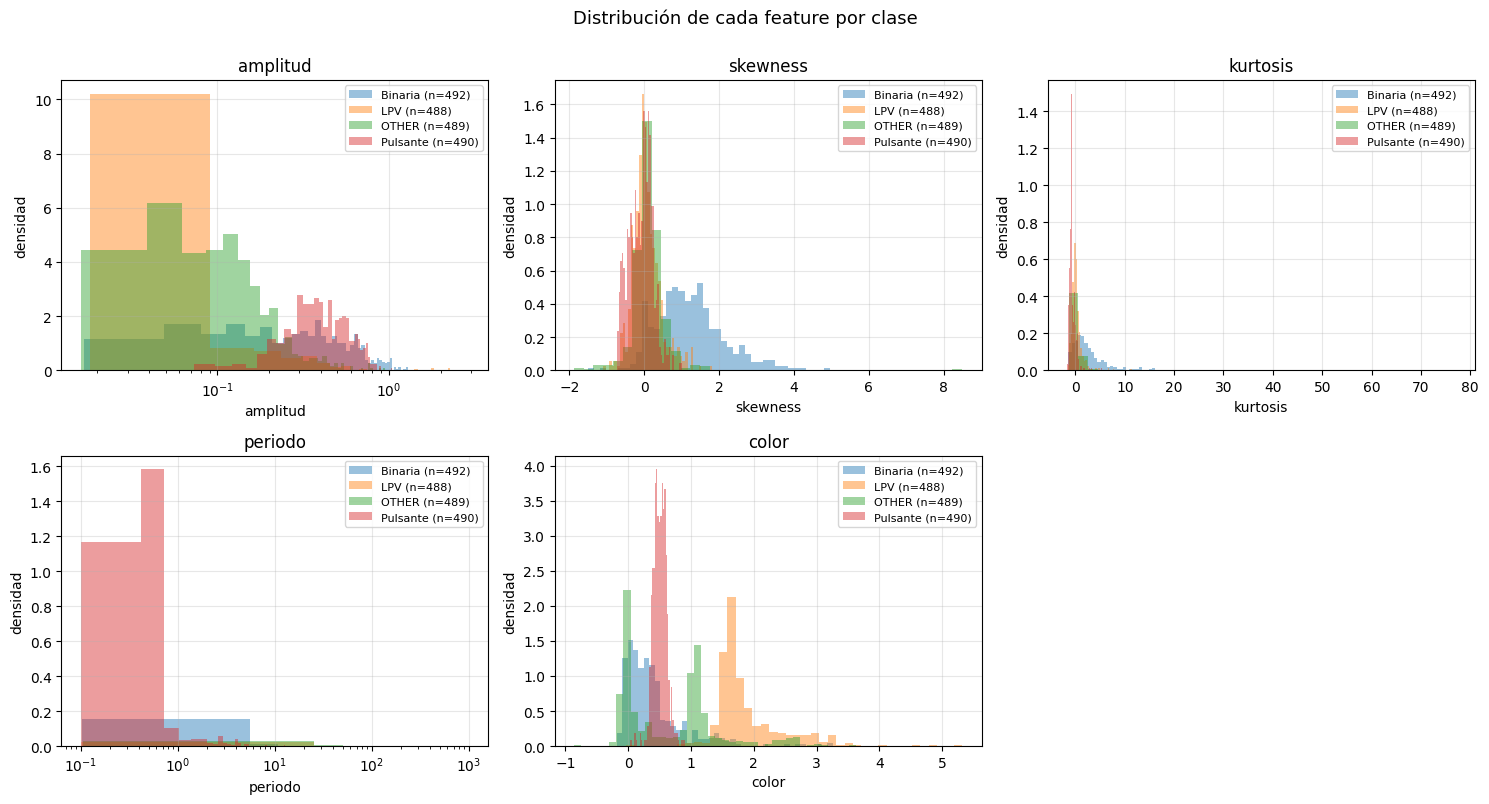

In [17]:
# %% [markdown]
# ## Paso 2 + 3: Spearman completo + histogramas por clase
# - Matriz de Spearman con las 6 features (incluyendo skewness y kurtosis)
# - Histogramas de cada feature separados por clase, para ver cuáles
#   discriminan visualmente

# %%

# Features a evaluar — solo las que existan en muestra
features = ['amplitud', 'skewness', 'kurtosis', 'periodo', 'color']
features = [f for f in features if f in muestra.columns]

# Filtrar a estrellas con TODAS las features válidas
datos = muestra.dropna(subset=features + ['clase']).copy()
print(f'Trabajando con {len(datos)} estrellas (de {len(muestra)} totales)')
print(datos['clase'].value_counts())

# %% Matriz de Spearman (todas las features)
corr = datos[features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=10)
fig.colorbar(im, label='Spearman ρ')
ax.set_title('Matriz de correlación de Spearman — 5 features')
plt.tight_layout()
plt.savefig('matrizspearman.png')
plt.show()

print('\nMatriz numérica:')
print(corr.round(2))

# %% Histogramas por clase — el test visual de "qué feature sirve"
clases = sorted(datos['clase'].unique())
# colores fijos por clase (consistencia entre subplots)
colores = dict(zip(clases, ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']))

# Features que se ven mejor en escala log (rango de varios órdenes de magnitud)
log_features = {'periodo', 'amplitud'}

n = len(features)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    for cl in clases:
        vals = datos.loc[datos['clase'] == cl, feat].dropna()
        if feat in log_features:
            vals = vals[vals > 0]   # log no acepta ≤ 0
        ax.hist(vals, bins=40, alpha=0.45, density=True,
                label=f'{cl} (n={len(vals)})', color=colores[cl])
    ax.set_xlabel(feat)
    ax.set_ylabel('densidad')
    if feat in log_features:
        ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.set_title(feat)
    ax.grid(alpha=0.3)

# Ocultar axes sobrantes si features < nrows*ncols
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Distribución de cada feature por clase', y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig('Todoshisto.png')
plt.show()

Estrellas usables: 1959 de 2000

Distribución por clase:
clase
Binaria     492
Pulsante    490
OTHER       489
LPV         488
Name: count, dtype: int64

Train: 1469 estrellas
Test:  490 estrellas
Entrenando Random Forest...

OOB score (estimación interna): 0.904

=== Random Forest — classification report (test) ===
              precision    recall  f1-score   support

     Binaria      0.896     0.837     0.866       123
         LPV      0.908     0.975     0.941       122
       OTHER      0.851     0.844     0.848       122
    Pulsante      0.943     0.943     0.943       123

    accuracy                          0.900       490
   macro avg      0.900     0.900     0.899       490
weighted avg      0.900     0.900     0.899       490



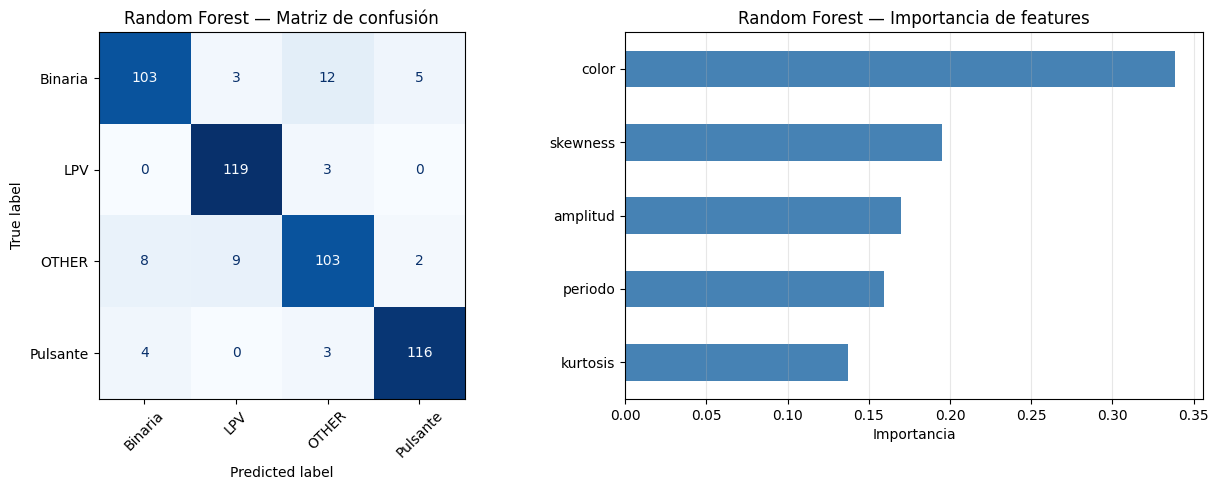

Entrenando Gradient Boosting (más lento, es secuencial)...

=== Gradient Boosting — classification report (test) ===
              precision    recall  f1-score   support

     Binaria      0.861     0.854     0.857       123
         LPV      0.944     0.959     0.951       122
       OTHER      0.846     0.852     0.849       122
    Pulsante      0.959     0.943     0.951       123

    accuracy                          0.902       490
   macro avg      0.902     0.902     0.902       490
weighted avg      0.902     0.902     0.902       490



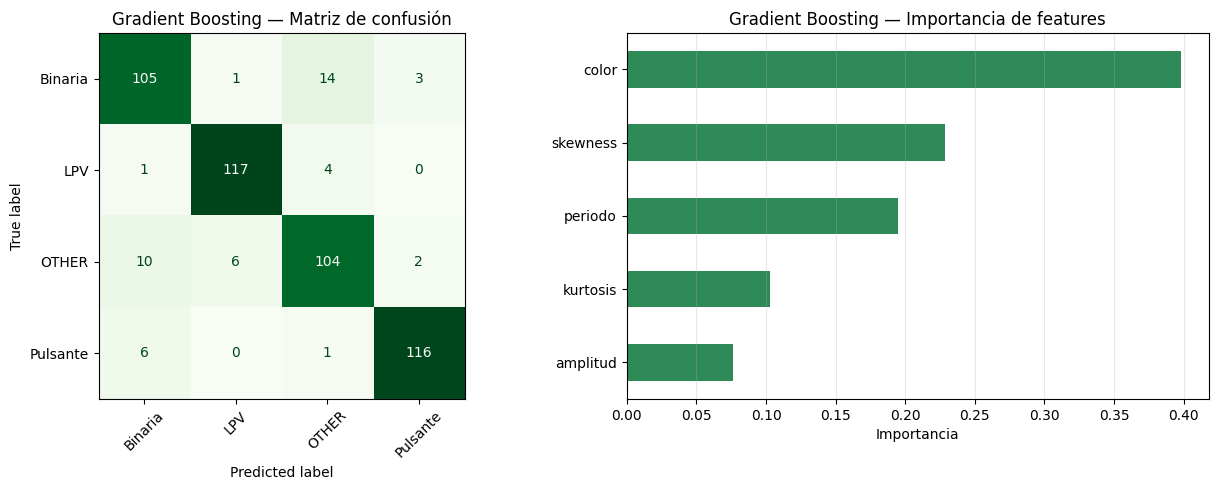


=== Resumen comparativo (set de TEST) ===
                   Accuracy  F1 macro  F1 weighted
Random Forest         0.900     0.899        0.899
Gradient Boosting     0.902     0.902        0.902


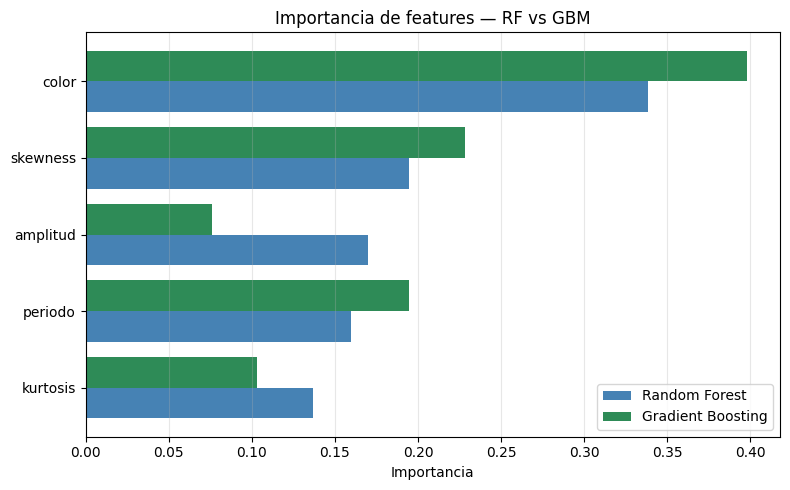


=== Validación cruzada (5-fold estratificada, F1 macro) ===
Random Forest:     0.907 ± 0.005
Gradient Boosting: 0.913 ± 0.006

Si las desviaciones se solapan, los modelos son estadísticamente equivalentes.

=== Cantidad y tipo de estrellas (test set) ===
          Real  Pred. RF  Pred. GBM
Binaria    123       115        122
LPV        122       131        124
OTHER      122       121        123
Pulsante   123       123        121

Modelos guardados: modelo_rf.pkl, modelo_gbm.pkl


In [18]:
# %% [markdown]
# ## Paso 4: Entrenamiento y evaluación — Random Forest y Gradient Boosting
#
# Requisito: `muestra` ya tiene calculadas las 5 features intrínsecas
# (`amplitud`, `periodo`, `color`, `skewness`, `kurtosis`) y la columna `clase`.

# %% Imports y configuración


from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              accuracy_score, f1_score)

FEATURES = ['amplitud', 'periodo', 'color', 'skewness', 'kurtosis']


# %% Preparación de datos
# Filtrar a estrellas con TODAS las features válidas
datos = muestra.dropna(subset=FEATURES + ['clase']).copy()
print(f'Estrellas usables: {len(datos)} de {len(muestra)}')
print('\nDistribución por clase:')
print(datos['clase'].value_counts())

X = datos[FEATURES]
y = datos['clase']


# %% Train / Test split (estratificado por clase, 75 / 25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} estrellas')
print(f'Test:  {X_test.shape[0]} estrellas')


# %% --- MODELO 1: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,          # 300 árboles
    max_features='sqrt',       # √5 ≈ 2 features por split (subespacio aleatorio)
    max_depth=None,            # árboles profundos (low bias, high variance)
    min_samples_leaf=1,        # default
    class_weight='balanced',   # por seguridad (clases casi balanceadas)
    oob_score=True,            # validación interna out-of-bag
    random_state=42,
    n_jobs=-1                  # paraleliza usando todos los núcleos
)

print('Entrenando Random Forest...')
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(f'\nOOB score (estimación interna): {rf.oob_score_:.3f}')
print('\n=== Random Forest — classification report (test) ===')
print(classification_report(y_test, pred_rf, digits=3))


# %% RF — Matriz de confusión + Importancia de features
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test, ax=axes[0], cmap='Blues',
    xticks_rotation=45, colorbar=False
)
axes[0].set_title('Random Forest — Matriz de confusión')

imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp_rf.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Random Forest — Importancia de features')
axes[1].set_xlabel('Importancia')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('randomforest.png')
plt.show()


# %% --- MODELO 2: Gradient Boosting Machine ---
gbm = GradientBoostingClassifier(
    n_estimators=200,    # 200 árboles secuenciales (menos que RF)
    learning_rate=0.1,   # ν de la fórmula F_m = F_{m-1} + ν·h_m
    max_depth=3,         # weak learners superficiales
    subsample=1.0,       # sin stochastic boosting
    random_state=42,
)

print('Entrenando Gradient Boosting (más lento, es secuencial)...')
gbm.fit(X_train, y_train)
pred_gbm = gbm.predict(X_test)

print('\n=== Gradient Boosting — classification report (test) ===')
print(classification_report(y_test, pred_gbm, digits=3))



fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    gbm, X_test, y_test, ax=axes[0], cmap='Greens',
    xticks_rotation=45, colorbar=False
)
axes[0].set_title('Gradient Boosting — Matriz de confusión')

imp_gbm = pd.Series(gbm.feature_importances_, index=FEATURES).sort_values()
imp_gbm.plot.barh(ax=axes[1], color='seagreen')
axes[1].set_title('Gradient Boosting — Importancia de features')
axes[1].set_xlabel('Importancia')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('Gradient.png')
plt.show()


resumen = pd.DataFrame({
    'Accuracy':    [accuracy_score(y_test, pred_rf),
                    accuracy_score(y_test, pred_gbm)],
    'F1 macro':    [f1_score(y_test, pred_rf, average='macro'),
                    f1_score(y_test, pred_gbm, average='macro')],
    'F1 weighted': [f1_score(y_test, pred_rf, average='weighted'),
                    f1_score(y_test, pred_gbm, average='weighted')],
}, index=['Random Forest', 'Gradient Boosting'])

print('\n=== Resumen comparativo (set de TEST) ===')
print(resumen.round(3))


fig, ax = plt.subplots(figsize=(8, 5))
orden = imp_rf.sort_values(ascending=True).index.tolist()
xpos = np.arange(len(FEATURES))
ancho = 0.4

ax.barh(xpos - ancho/2, [imp_rf[f] for f in orden],  ancho,
        label='Random Forest', color='steelblue')
ax.barh(xpos + ancho/2, [imp_gbm[f] for f in orden], ancho,
        label='Gradient Boosting', color='seagreen')
ax.set_yticks(xpos)
ax.set_yticklabels(orden)
ax.set_xlabel('Importancia')
ax.set_title('Importancia de features — RF vs GBM')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()



print('\n=== Validación cruzada (5-fold estratificada, F1 macro) ===')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf  = cross_val_score(rf,  X, y, cv=cv, scoring='f1_macro')
cv_gbm = cross_val_score(gbm, X, y, cv=cv, scoring='f1_macro')

print(f'Random Forest:     {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')
print(f'Gradient Boosting: {cv_gbm.mean():.3f} ± {cv_gbm.std():.3f}')
print('\nSi las desviaciones se solapan, los modelos son estadísticamente equivalentes.')



conteo_real = y_test.value_counts().sort_index()
conteo_rf   = pd.Series(pred_rf).value_counts().sort_index()
conteo_gbm  = pd.Series(pred_gbm).value_counts().sort_index()

resumen_conteo = pd.DataFrame({
    'Real':      conteo_real,
    'Pred. RF':  conteo_rf,
    'Pred. GBM': conteo_gbm,
}).fillna(0).astype(int)

print('\n=== Cantidad y tipo de estrellas (test set) ===')
print(resumen_conteo)


# %% Guardar los modelos entrenados (opcional pero recomendado)
import joblib
joblib.dump(rf,  'modelo_rf.pkl')
joblib.dump(gbm, 'modelo_gbm.pkl')
print('\nModelos guardados: modelo_rf.pkl, modelo_gbm.pkl')



df2: 6789 estrellas en el catálogo
rf entrenado: True
gbm entrenado: True
Distribución real en el catálogo completo:
clase
LPV         2799
Binaria     1532
OTHER       1473
Pulsante     985
Name: count, dtype: int64

Calculando features para el catálogo completo...


100%|██████████| 6789/6789 [13:05<00:00,  8.64it/s]



Estrellas usables en el catálogo completo: 1959 de 6789

Distribución por clase (real):
clase
LPV         730
OTHER       487
Binaria     457
Pulsante    285
Name: count, dtype: int64

Prediciendo con los dos modelos...

=== Random Forest — catálogo completo ===
              precision    recall  f1-score   support

     Binaria      0.731     0.691     0.711       457
         LPV      0.448     0.303     0.361       730
       OTHER      0.406     0.686     0.510       487
    Pulsante      0.848     0.628     0.722       285

    accuracy                          0.536      1959
   macro avg      0.608     0.577     0.576      1959
weighted avg      0.562     0.536     0.532      1959


=== Gradient Boosting — catálogo completo ===
              precision    recall  f1-score   support

     Binaria      0.771     0.729     0.749       457
         LPV      0.583     0.371     0.454       730
       OTHER      0.434     0.741     0.548       487
    Pulsante      0.835     0.677    

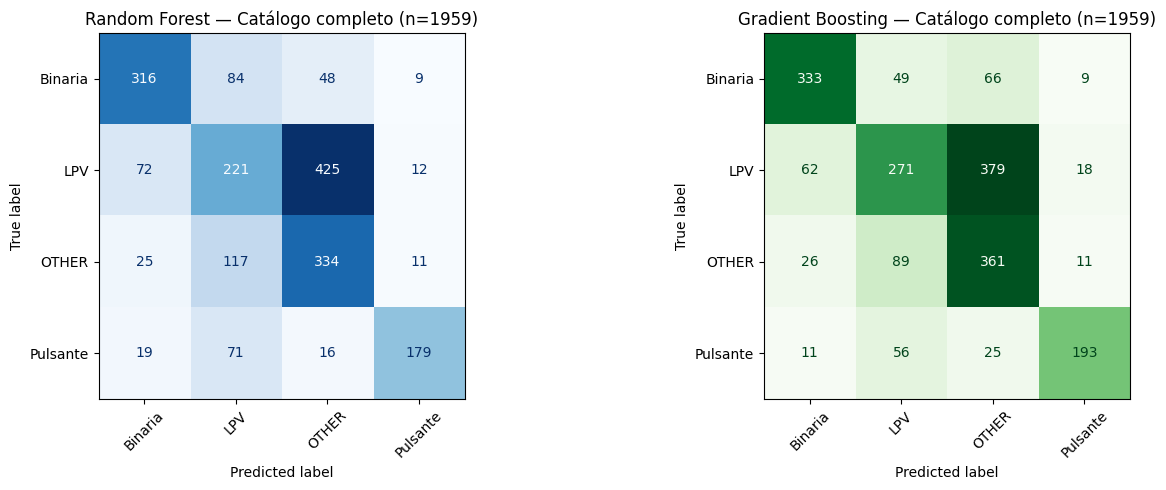


=== Cantidad por clase — catálogo completo ===
          Real  Pred. RF  Pred. GBM
Binaria    457       432        432
LPV        730       493        465
OTHER      487       823        831
Pulsante   285       211        231


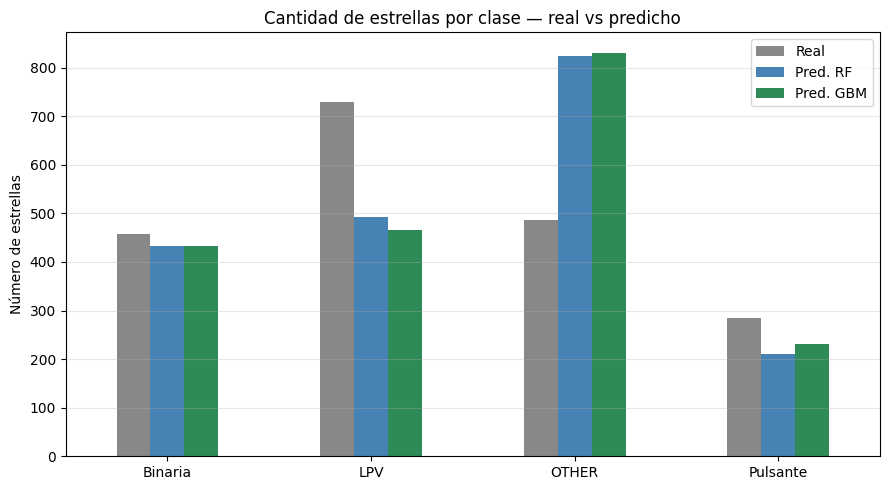


Predicciones guardadas: predicciones_catalogo_completo.csv (1959 filas)


In [19]:
# %% [markdown]
# ## Aplicación del modelo entrenado al catálogo completo (~7000 estrellas)
#
# Hasta ahora hemos trabajado con una muestra balanceada de ~2000 estrellas.
# Aquí aplicamos los modelos entrenados (`rf` y `gbm`) a TODAS las estrellas
# del catálogo y comparamos con las etiquetas verdaderas para ver qué tan
# bien generaliza fuera de la muestra.
#
# Requisitos: `df2` (catálogo completo), `features_estrella` (función del paso 1),
# y los modelos `rf`, `gbm` ya entrenados en memoria.

# %% Verificación inicial


from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(f'df2: {len(df2)} estrellas en el catálogo')
print(f'rf entrenado: {hasattr(rf, "classes_")}')
print(f'gbm entrenado: {hasattr(gbm, "classes_")}')

FEATURES = ['amplitud', 'periodo', 'color', 'skewness', 'kurtosis']


# %% Asignar clase al catálogo completo (mismo mapping que en tu celda 1)
# AJUSTA tipo_a_clase a lo que usaste originalmente, o salta esta celda
# si df2 ya tiene la columna 'clase'

if 'clase' not in df2.columns:
    tipo_a_clase = {
        'RRLYR': 'Pulsante',
        'CEP':   'Pulsante',
        'T2CEP': 'Pulsante',
        'DSCT':  'Pulsante',
        'ACEP':  'Pulsante',
        'ECL':   'Binaria',
        'LPV':   'LPV',
        # cualquier otro tipo → 'OTHER'
    }
    df2['clase'] = df2.iloc[:, 3].map(tipo_a_clase).fillna('OTHER')

print('Distribución real en el catálogo completo:')
print(df2['clase'].value_counts())


# %% Calcular features para TODAS las estrellas del catálogo
# ESTA es la celda lenta. Para ~7000 estrellas, espera varios minutos.
print('\nCalculando features para el catálogo completo...')
features_full = df2.iloc[:, col_id].progress_apply(features_estrella)
for c in features_full.columns:
    df2[c] = features_full[c].values


# %% Calcular color limpio para todo el catálogo
# AJUSTA los índices [6, 7] y la convención de resta a la que terminaste usando


col6 = pd.to_numeric(muestra.iloc[:, 6], errors='coerce')
col5 = pd.to_numeric(muestra.iloc[:, 5], errors='coerce')
df2['color'] = col6 - col5

''' 
mag_a = df2.iloc[:, 5].copy()
mag_b = df2.iloc[:, 6].copy()

mascara_mala = (mag_a > 50) | (mag_a < 0) | (mag_b > 50) | (mag_b < 0)
mag_a[mascara_mala] = np.nan
mag_b[mascara_mala] = np.nan
df2['color'] = mag_b - mag_a
'''


# %% Filtrar a estrellas con todas las features válidas
datos_full = df2.dropna(subset=FEATURES + ['clase']).copy()
print(f'\nEstrellas usables en el catálogo completo: {len(datos_full)} de {len(df2)}')
print('\nDistribución por clase (real):')
print(datos_full['clase'].value_counts())

X_full = datos_full[FEATURES]
y_full = datos_full['clase']


# %% PREDICCIÓN con los dos modelos
print('\nPrediciendo con los dos modelos...')
pred_rf_full  = rf.predict(X_full)
pred_gbm_full = gbm.predict(X_full)


# %% Evaluación: classification report en el catálogo completo
# NOTA: este conjunto incluye las ~1450 estrellas usadas para entrenar;
# los números aquí son ligeramente optimistas respecto al "rendimiento real
# sobre datos no vistos" (que es lo que mide el test set en el paso 4).
print('\n=== Random Forest — catálogo completo ===')
print(classification_report(y_full, pred_rf_full, digits=3))

print('\n=== Gradient Boosting — catálogo completo ===')
print(classification_report(y_full, pred_gbm_full, digits=3))


# %% Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_full, pred_rf_full, ax=axes[0], cmap='Blues',
    xticks_rotation=45, colorbar=False
)
axes[0].set_title(f'Random Forest — Catálogo completo (n={len(y_full)})')

ConfusionMatrixDisplay.from_predictions(
    y_full, pred_gbm_full, ax=axes[1], cmap='Greens',
    xticks_rotation=45, colorbar=False
)
axes[1].set_title(f'Gradient Boosting — Catálogo completo (n={len(y_full)})')

plt.tight_layout()
plt.show()


# %% Cantidad por clase — real vs predicho (la "cantidad y tipo" del enunciado)
comparacion = pd.DataFrame({
    'Real':      pd.Series(y_full).value_counts().sort_index(),
    'Pred. RF':  pd.Series(pred_rf_full).value_counts().sort_index(),
    'Pred. GBM': pd.Series(pred_gbm_full).value_counts().sort_index(),
}).fillna(0).astype(int)

print('\n=== Cantidad por clase — catálogo completo ===')
print(comparacion)

# Visualización en barras
ax = comparacion.plot.bar(figsize=(9, 5), rot=0,
                          color=['#888888', 'steelblue', 'seagreen'])
ax.set_ylabel('Número de estrellas')
ax.set_title('Cantidad de estrellas por clase — real vs predicho')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# %% Guardar predicciones a CSV (para tener el resultado completo)
salida = pd.DataFrame({
    'star_id':        datos_full.iloc[:, col_id].values,
    'clase_real':     y_full.values,
    'clase_pred_rf':  pred_rf_full,
    'clase_pred_gbm': pred_gbm_full,
})
salida.to_csv('predicciones_catalogo_completo.csv', index=False)
print(f'\nPredicciones guardadas: predicciones_catalogo_completo.csv ({len(salida)} filas)')


# %% [markdown]
# ### Notas sobre la interpretación
#
# - **Las clases que el modelo predice mejor en el test set (LPV, Pulsante)
#   deberían seguir saliendo bien aquí.** Si en el catálogo completo aparecen
#   con un recall similar al que vimos en el paso 4 (~94-97%), el modelo
#   generaliza bien.
# - **El balance del catálogo es muy distinto al del entrenamiento.** En OGLE-LMC
#   las LPVs (especialmente OSARGs) suelen ser la clase más numerosa. Si las
#   predicciones siguen la misma proporción real → el modelo NO está sesgado
#   a la distribución balanceada del entrenamiento. Si las sub/sobre-estima,
#   sí hay sesgo y conviene mencionarlo en la discusión.
# - **Hay un sesgo "optimista" leve** en estas métricas porque las ~1450
#   estrellas del entrenamiento están incluidas. La métrica honesta sigue
#   siendo la del paso 4 (test set puro). Lo de aquí es la *aplicación* real
#   del modelo a todo el catálogo, que es lo que pide el enunciado.

In [20]:
import os

total = len(df2)
sin_amplitud = df2['amplitud'].isna().sum()   # features no se calcularon (file/poco data)
sin_color    = df2['color'].isna().sum()      # color falló
sin_clase    = df2['clase'].isna().sum()      # tipo no mapeable

print(f'Total en df2:           {total}')
print(f'Sin amplitud (file/<20 pts): {sin_amplitud}  ({100*sin_amplitud/total:.1f}%)')
print(f'Sin color:                   {sin_color}     ({100*sin_color/total:.1f}%)')
print(f'Sin clase:                   {sin_clase}     ({100*sin_clase/total:.1f}%)')

# De las que fallaron en features, ¿cuántas es porque el archivo no existía?
fallidas = df2[df2['amplitud'].isna()].iloc[:20, col_id]
print('\nDe una muestra de 20 que fallaron en features:')
existen = 0
for sid in fallidas:
    if os.path.exists(os.path.join(BASE, f'{sid}.dat')):
        existen += 1
print(f'{existen}/20 tienen archivo en BASE, {20-existen}/20 NO')

Total en df2:           6789
Sin amplitud (file/<20 pts): 0  (0.0%)
Sin color:                   4830     (71.1%)
Sin clase:                   0     (0.0%)

De una muestra de 20 que fallaron en features:
0/20 tienen archivo en BASE, 20/20 NO


Estrellas usables: 2000 de 2000

Distribución por clase:
clase
Binaria     500
LPV         500
OTHER       500
Pulsante    500
Name: count, dtype: int64



Train: 1500 estrellas
Test:  500 estrellas
Entrenando Random Forest...

OOB score (estimación interna): 0.849

=== Random Forest — classification report (test) ===
              precision    recall  f1-score   support

     Binaria      0.857     0.864     0.861       125
         LPV      0.793     0.888     0.838       125
       OTHER      0.792     0.672     0.727       125
    Pulsante      0.945     0.968     0.957       125

    accuracy                          0.848       500
   macro avg      0.847     0.848     0.846       500
weighted avg      0.847     0.848     0.846       500



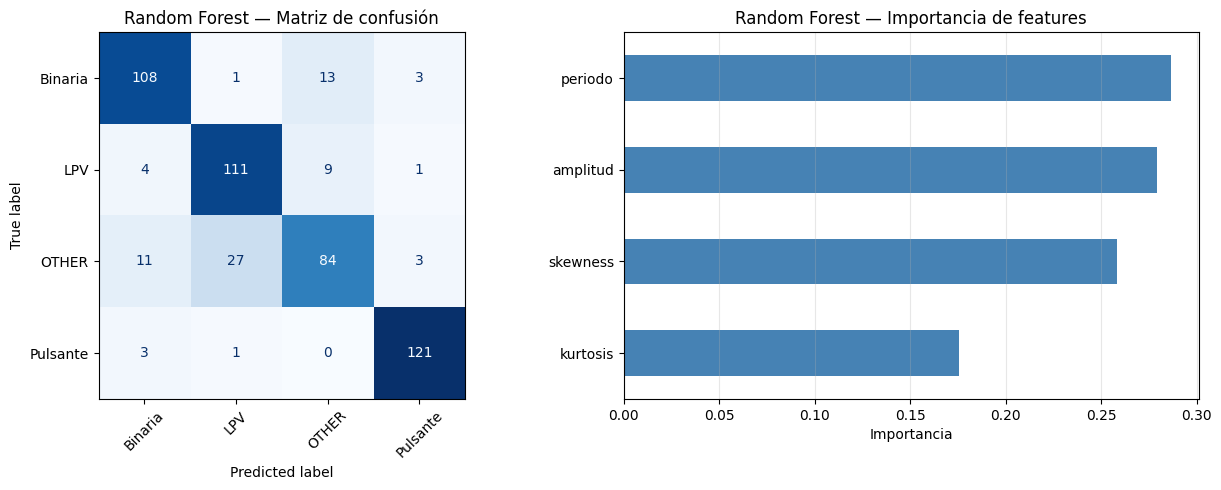

Entrenando Gradient Boosting (más lento, es secuencial)...

=== Gradient Boosting — classification report (test) ===
              precision    recall  f1-score   support

     Binaria      0.869     0.848     0.858       125
         LPV      0.824     0.896     0.858       125
       OTHER      0.804     0.720     0.759       125
    Pulsante      0.931     0.968     0.949       125

    accuracy                          0.858       500
   macro avg      0.857     0.858     0.856       500
weighted avg      0.857     0.858     0.856       500



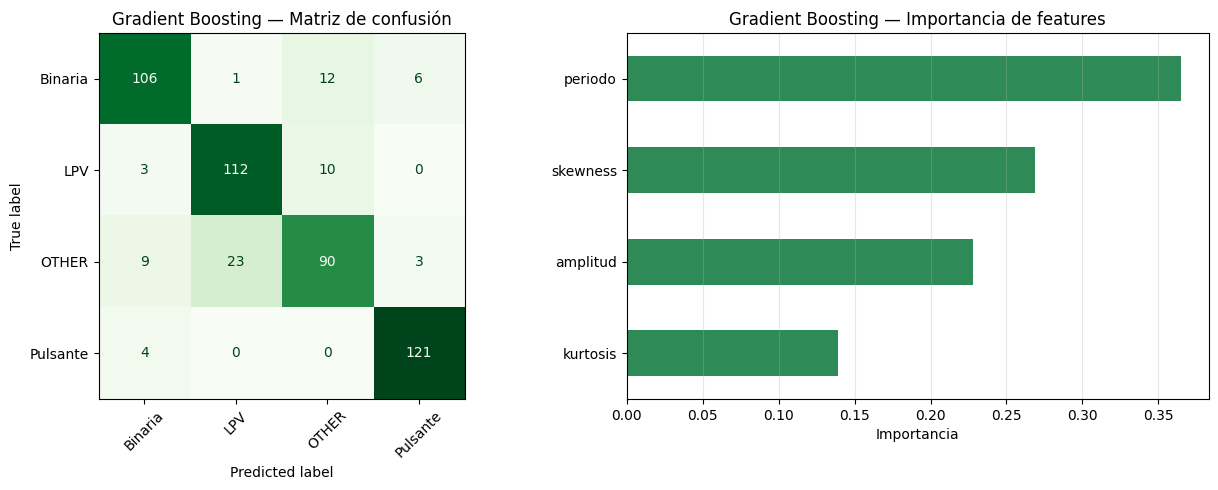


=== Resumen comparativo (set de TEST) ===
                   Accuracy  F1 macro  F1 weighted
Random Forest         0.848     0.846        0.846
Gradient Boosting     0.858     0.856        0.856


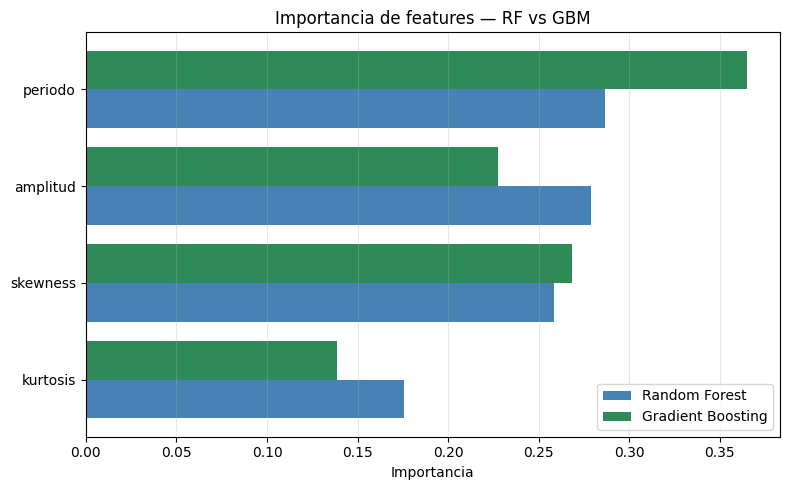


=== Validación cruzada (5-fold estratificada, F1 macro) ===
Random Forest:     0.848 ± 0.016
Gradient Boosting: 0.862 ± 0.025

Si las desviaciones se solapan, los modelos son estadísticamente equivalentes.

=== Cantidad y tipo de estrellas (test set) ===
          Real  Pred. RF  Pred. GBM
Binaria    125       126        122
LPV        125       140        136
OTHER      125       106        112
Pulsante   125       128        130

Modelos guardados: modelo_rf.pkl, modelo_gbm.pkl


In [21]:
# %% [markdown]
# ## Paso 4: Entrenamiento y evaluación — Random Forest y Gradient Boosting
#
# Requisito: `muestra` ya tiene calculadas las 5 features intrínsecas
# (`amplitud`, `periodo`, `color`, `skewness`, `kurtosis`) y la columna `clase`.

# %% Imports y configuración


from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              accuracy_score, f1_score)

FEATURES = ['amplitud', 'periodo', 'skewness', 'kurtosis']


# %% Preparación de datos
# Filtrar a estrellas con TODAS las features válidas
datos = muestra.dropna(subset=FEATURES + ['clase']).copy()
print(f'Estrellas usables: {len(datos)} de {len(muestra)}')
print('\nDistribución por clase:')
print(datos['clase'].value_counts())

X = datos[FEATURES]
y = datos['clase']


# %% Train / Test split (estratificado por clase, 75 / 25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} estrellas')
print(f'Test:  {X_test.shape[0]} estrellas')


# %% --- MODELO 1: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,          # 300 árboles
    max_features='sqrt',       # √5 ≈ 2 features por split (subespacio aleatorio)
    max_depth=None,            # árboles profundos (low bias, high variance)
    min_samples_leaf=1,        # default
    class_weight='balanced',   # por seguridad (clases casi balanceadas)
    oob_score=True,            # validación interna out-of-bag
    random_state=42,
    n_jobs=-1                  # paraleliza usando todos los núcleos
)

print('Entrenando Random Forest...')
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(f'\nOOB score (estimación interna): {rf.oob_score_:.3f}')
print('\n=== Random Forest — classification report (test) ===')
print(classification_report(y_test, pred_rf, digits=3))


# %% RF — Matriz de confusión + Importancia de features
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test, ax=axes[0], cmap='Blues',
    xticks_rotation=45, colorbar=False
)
axes[0].set_title('Random Forest — Matriz de confusión')

imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp_rf.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Random Forest — Importancia de features')
axes[1].set_xlabel('Importancia')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('randomforest.png')
plt.show()


# %% --- MODELO 2: Gradient Boosting Machine ---
gbm = GradientBoostingClassifier(
    n_estimators=200,    # 200 árboles secuenciales (menos que RF)
    learning_rate=0.1,   # ν de la fórmula F_m = F_{m-1} + ν·h_m
    max_depth=3,         # weak learners superficiales
    subsample=1.0,       # sin stochastic boosting
    random_state=42,
)

print('Entrenando Gradient Boosting (más lento, es secuencial)...')
gbm.fit(X_train, y_train)
pred_gbm = gbm.predict(X_test)

print('\n=== Gradient Boosting — classification report (test) ===')
print(classification_report(y_test, pred_gbm, digits=3))



fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    gbm, X_test, y_test, ax=axes[0], cmap='Greens',
    xticks_rotation=45, colorbar=False
)
axes[0].set_title('Gradient Boosting — Matriz de confusión')

imp_gbm = pd.Series(gbm.feature_importances_, index=FEATURES).sort_values()
imp_gbm.plot.barh(ax=axes[1], color='seagreen')
axes[1].set_title('Gradient Boosting — Importancia de features')
axes[1].set_xlabel('Importancia')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('Gradient.png')
plt.show()


resumen = pd.DataFrame({
    'Accuracy':    [accuracy_score(y_test, pred_rf),
                    accuracy_score(y_test, pred_gbm)],
    'F1 macro':    [f1_score(y_test, pred_rf, average='macro'),
                    f1_score(y_test, pred_gbm, average='macro')],
    'F1 weighted': [f1_score(y_test, pred_rf, average='weighted'),
                    f1_score(y_test, pred_gbm, average='weighted')],
}, index=['Random Forest', 'Gradient Boosting'])

print('\n=== Resumen comparativo (set de TEST) ===')
print(resumen.round(3))


fig, ax = plt.subplots(figsize=(8, 5))
orden = imp_rf.sort_values(ascending=True).index.tolist()
xpos = np.arange(len(FEATURES))
ancho = 0.4

ax.barh(xpos - ancho/2, [imp_rf[f] for f in orden],  ancho,
        label='Random Forest', color='steelblue')
ax.barh(xpos + ancho/2, [imp_gbm[f] for f in orden], ancho,
        label='Gradient Boosting', color='seagreen')
ax.set_yticks(xpos)
ax.set_yticklabels(orden)
ax.set_xlabel('Importancia')
ax.set_title('Importancia de features — RF vs GBM')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()



print('\n=== Validación cruzada (5-fold estratificada, F1 macro) ===')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf  = cross_val_score(rf,  X, y, cv=cv, scoring='f1_macro')
cv_gbm = cross_val_score(gbm, X, y, cv=cv, scoring='f1_macro')

print(f'Random Forest:     {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')
print(f'Gradient Boosting: {cv_gbm.mean():.3f} ± {cv_gbm.std():.3f}')
print('\nSi las desviaciones se solapan, los modelos son estadísticamente equivalentes.')



conteo_real = y_test.value_counts().sort_index()
conteo_rf   = pd.Series(pred_rf).value_counts().sort_index()
conteo_gbm  = pd.Series(pred_gbm).value_counts().sort_index()

resumen_conteo = pd.DataFrame({
    'Real':      conteo_real,
    'Pred. RF':  conteo_rf,
    'Pred. GBM': conteo_gbm,
}).fillna(0).astype(int)

print('\n=== Cantidad y tipo de estrellas (test set) ===')
print(resumen_conteo)


# %% Guardar los modelos entrenados (opcional pero recomendado)
import joblib
joblib.dump(rf,  'modelo_rf.pkl')
joblib.dump(gbm, 'modelo_gbm.pkl')
print('\nModelos guardados: modelo_rf.pkl, modelo_gbm.pkl')



df2: 6789 estrellas en el catálogo
rf entrenado: True
gbm entrenado: True
Distribución real en el catálogo completo:
clase
LPV         2799
Binaria     1532
OTHER       1473
Pulsante     985
Name: count, dtype: int64

Calculando features para el catálogo completo...


100%|██████████| 6789/6789 [13:27<00:00,  8.40it/s]



Estrellas usables en el catálogo completo: 6789 de 6789

Distribución por clase (real):
clase
LPV         2799
Binaria     1532
OTHER       1473
Pulsante     985
Name: count, dtype: int64

Prediciendo con los dos modelos...

=== Random Forest — catálogo completo ===
              precision    recall  f1-score   support

     Binaria      0.892     0.860     0.876      1532
         LPV      0.914     0.875     0.894      2799
       OTHER      0.747     0.803     0.774      1473
    Pulsante      0.912     0.972     0.941       985

    accuracy                          0.870      6789
   macro avg      0.866     0.877     0.871      6789
weighted avg      0.873     0.870     0.871      6789


=== Gradient Boosting — catálogo completo ===
              precision    recall  f1-score   support

     Binaria      0.907     0.846     0.875      1532
         LPV      0.921     0.871     0.895      2799
       OTHER      0.716     0.815     0.762      1473
    Pulsante      0.919     0.968

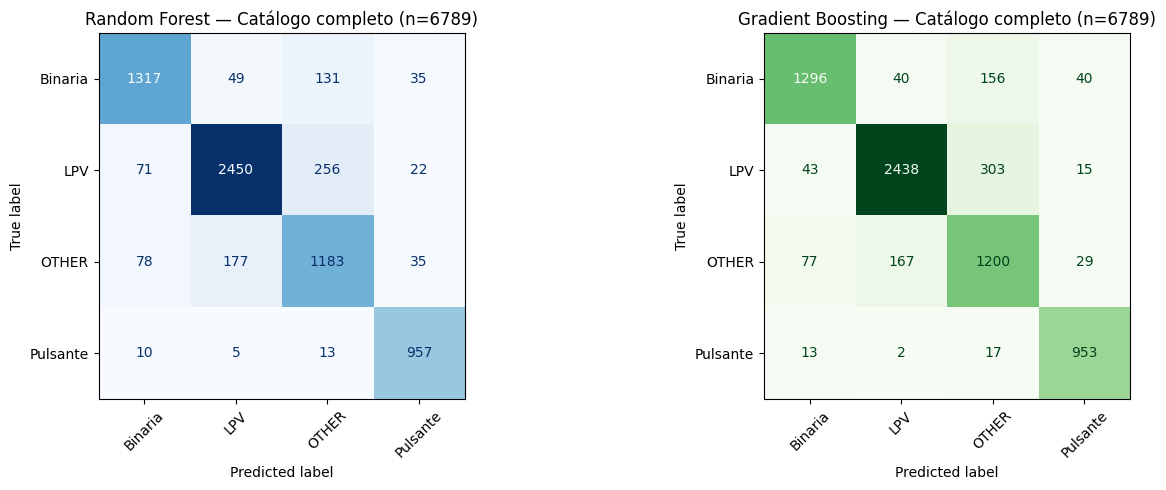


=== Cantidad por clase — catálogo completo ===
          Real  Pred. RF  Pred. GBM
Binaria   1532      1476       1429
LPV       2799      2681       2647
OTHER     1473      1583       1676
Pulsante   985      1049       1037


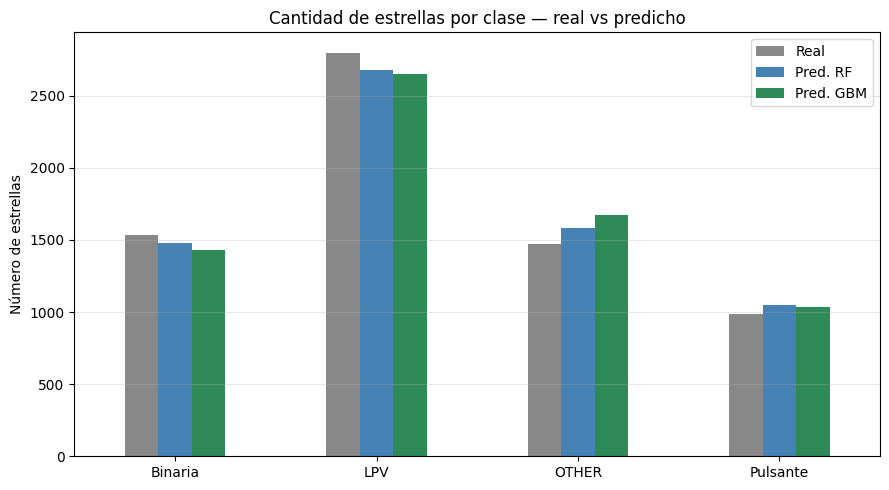


Predicciones guardadas: predicciones_catalogo_completo.csv (6789 filas)


In [22]:
# %% [markdown]
# ## Aplicación del modelo entrenado al catálogo completo (~7000 estrellas)
#
# Hasta ahora hemos trabajado con una muestra balanceada de ~2000 estrellas.
# Aquí aplicamos los modelos entrenados (`rf` y `gbm`) a TODAS las estrellas
# del catálogo y comparamos con las etiquetas verdaderas para ver qué tan
# bien generaliza fuera de la muestra.
#
# Requisitos: `df2` (catálogo completo), `features_estrella` (función del paso 1),
# y los modelos `rf`, `gbm` ya entrenados en memoria.

# %% Verificación inicial


from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(f'df2: {len(df2)} estrellas en el catálogo')
print(f'rf entrenado: {hasattr(rf, "classes_")}')
print(f'gbm entrenado: {hasattr(gbm, "classes_")}')

FEATURES = ['amplitud', 'periodo', 'skewness', 'kurtosis']


# %% Asignar clase al catálogo completo (mismo mapping que en tu celda 1)
# AJUSTA tipo_a_clase a lo que usaste originalmente, o salta esta celda
# si df2 ya tiene la columna 'clase'

if 'clase' not in df2.columns:
    tipo_a_clase = {
        'RRLYR': 'Pulsante',
        'CEP':   'Pulsante',
        'T2CEP': 'Pulsante',
        'DSCT':  'Pulsante',
        'ACEP':  'Pulsante',
        'ECL':   'Binaria',
        'LPV':   'LPV',
        # cualquier otro tipo → 'OTHER'
    }
    df2['clase'] = df2.iloc[:, 3].map(tipo_a_clase).fillna('OTHER')

print('Distribución real en el catálogo completo:')
print(df2['clase'].value_counts())


# %% Calcular features para TODAS las estrellas del catálogo
# ESTA es la celda lenta. Para ~7000 estrellas, espera varios minutos.
print('\nCalculando features para el catálogo completo...')
features_full = df2.iloc[:, col_id].progress_apply(features_estrella)
for c in features_full.columns:
    df2[c] = features_full[c].values


# %% Calcular color limpio para todo el catálogo
# AJUSTA los índices [6, 7] y la convención de resta a la que terminaste usando


'''
col6 = pd.to_numeric(muestra.iloc[:, 6], errors='coerce')
col5 = pd.to_numeric(muestra.iloc[:, 5], errors='coerce')
df2['color'] = col6 - col5
'''

''' 
mag_a = df2.iloc[:, 5].copy()
mag_b = df2.iloc[:, 6].copy()

mascara_mala = (mag_a > 50) | (mag_a < 0) | (mag_b > 50) | (mag_b < 0)
mag_a[mascara_mala] = np.nan
mag_b[mascara_mala] = np.nan
df2['color'] = mag_b - mag_a
'''


# %% Filtrar a estrellas con todas las features válidas
datos_full = df2.dropna(subset=FEATURES + ['clase']).copy()
print(f'\nEstrellas usables en el catálogo completo: {len(datos_full)} de {len(df2)}')
print('\nDistribución por clase (real):')
print(datos_full['clase'].value_counts())

X_full = datos_full[FEATURES]
y_full = datos_full['clase']


# %% PREDICCIÓN con los dos modelos
print('\nPrediciendo con los dos modelos...')
pred_rf_full  = rf.predict(X_full)
pred_gbm_full = gbm.predict(X_full)


# %% Evaluación: classification report en el catálogo completo
# NOTA: este conjunto incluye las ~1450 estrellas usadas para entrenar;
# los números aquí son ligeramente optimistas respecto al "rendimiento real
# sobre datos no vistos" (que es lo que mide el test set en el paso 4).
print('\n=== Random Forest — catálogo completo ===')
print(classification_report(y_full, pred_rf_full, digits=3))

print('\n=== Gradient Boosting — catálogo completo ===')
print(classification_report(y_full, pred_gbm_full, digits=3))


# %% Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_full, pred_rf_full, ax=axes[0], cmap='Blues',
    xticks_rotation=45, colorbar=False
)
axes[0].set_title(f'Random Forest — Catálogo completo (n={len(y_full)})')

ConfusionMatrixDisplay.from_predictions(
    y_full, pred_gbm_full, ax=axes[1], cmap='Greens',
    xticks_rotation=45, colorbar=False
)
axes[1].set_title(f'Gradient Boosting — Catálogo completo (n={len(y_full)})')

plt.tight_layout()
plt.show()


# %% Cantidad por clase — real vs predicho (la "cantidad y tipo" del enunciado)
comparacion = pd.DataFrame({
    'Real':      pd.Series(y_full).value_counts().sort_index(),
    'Pred. RF':  pd.Series(pred_rf_full).value_counts().sort_index(),
    'Pred. GBM': pd.Series(pred_gbm_full).value_counts().sort_index(),
}).fillna(0).astype(int)

print('\n=== Cantidad por clase — catálogo completo ===')
print(comparacion)

# Visualización en barras
ax = comparacion.plot.bar(figsize=(9, 5), rot=0,
                          color=['#888888', 'steelblue', 'seagreen'])
ax.set_ylabel('Número de estrellas')
ax.set_title('Cantidad de estrellas por clase — real vs predicho')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# %% Guardar predicciones a CSV (para tener el resultado completo)
salida = pd.DataFrame({
    'star_id':        datos_full.iloc[:, col_id].values,
    'clase_real':     y_full.values,
    'clase_pred_rf':  pred_rf_full,
    'clase_pred_gbm': pred_gbm_full,
})
salida.to_csv('predicciones_catalogo_completo.csv', index=False)
print(f'\nPredicciones guardadas: predicciones_catalogo_completo.csv ({len(salida)} filas)')


# %% [markdown]
# ### Notas sobre la interpretación
#
# - **Las clases que el modelo predice mejor en el test set (LPV, Pulsante)
#   deberían seguir saliendo bien aquí.** Si en el catálogo completo aparecen
#   con un recall similar al que vimos en el paso 4 (~94-97%), el modelo
#   generaliza bien.
# - **El balance del catálogo es muy distinto al del entrenamiento.** En OGLE-LMC
#   las LPVs (especialmente OSARGs) suelen ser la clase más numerosa. Si las
#   predicciones siguen la misma proporción real → el modelo NO está sesgado
#   a la distribución balanceada del entrenamiento. Si las sub/sobre-estima,
#   sí hay sesgo y conviene mencionarlo en la discusión.
# - **Hay un sesgo "optimista" leve** en estas métricas porque las ~1450
#   estrellas del entrenamiento están incluidas. La métrica honesta sigue
#   siendo la del paso 4 (test set puro). Lo de aquí es la *aplicación* real
#   del modelo a todo el catálogo, que es lo que pide el enunciado.